# Exploratory Data analysis

In [1]:
# To ignore non harmful warnings
from warnings import filterwarnings
filterwarnings('ignore')

### Read the 50 startups data

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\DELL\Downloads\50_Startups.csv")
df

,RND,ADMIN,MKT,STATE,PROFIT
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


### Data visualization - matplotlib, seaborn

In [ ]:
df = df.fillna(df.mean("RND"), axis = 0, inplace= True)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='RND', ylabel='PROFIT'>

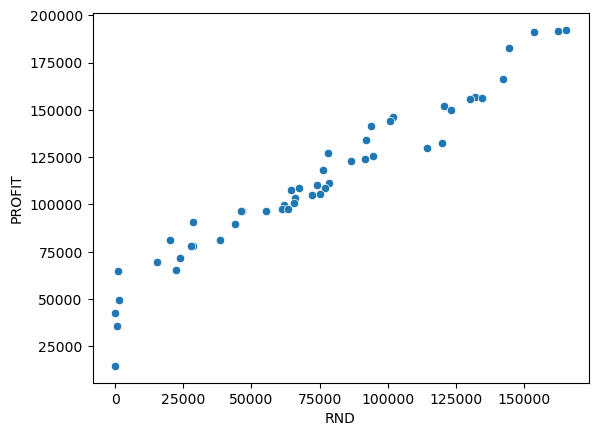

In [6]:
sns.scatterplot(data=df, x="RND", y="PROFIT")

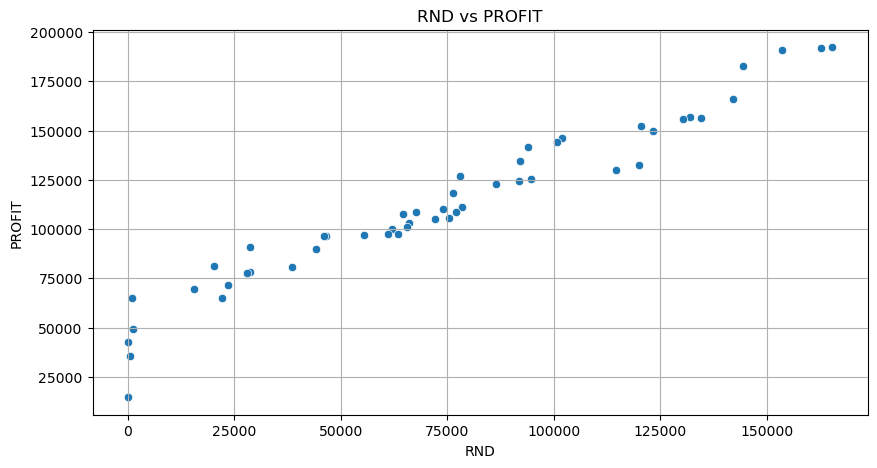

In [7]:
# Sequence is important here
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="RND", y="PROFIT")
plt.title("RND vs PROFIT")
plt.grid()
plt.show()

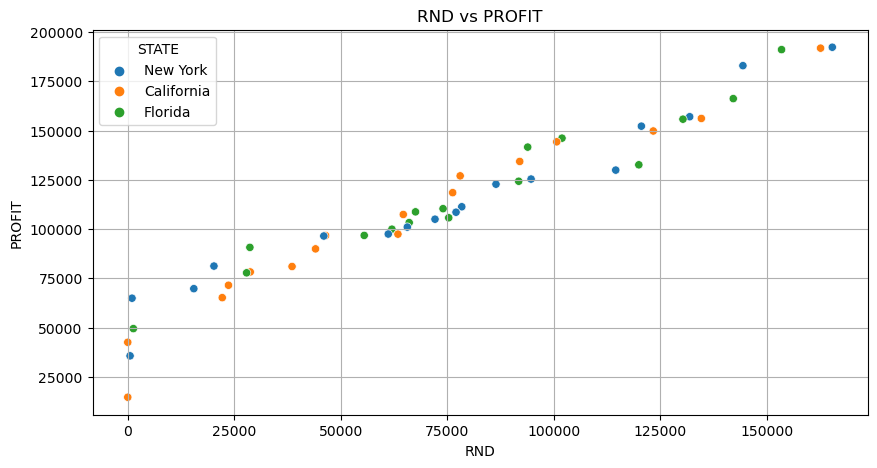

In [8]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="RND", y="PROFIT", hue="STATE")
plt.title("RND vs PROFIT")
plt.grid()
plt.show()

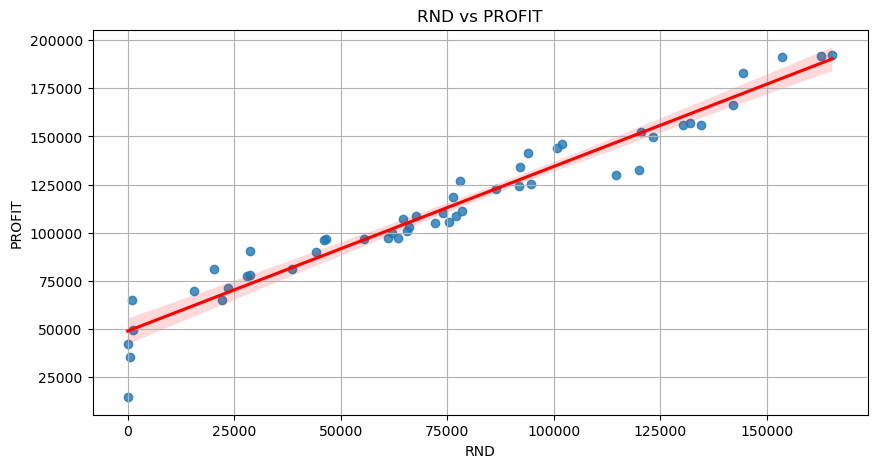

In [9]:
plt.figure(figsize=(10, 5))
sns.regplot(data=df, x="RND", y="PROFIT", line_kws={"color":"red"})
plt.title("RND vs PROFIT")
plt.grid()
plt.show()

### Conclusion AS RND increases PROFIT Also increases in a linear way

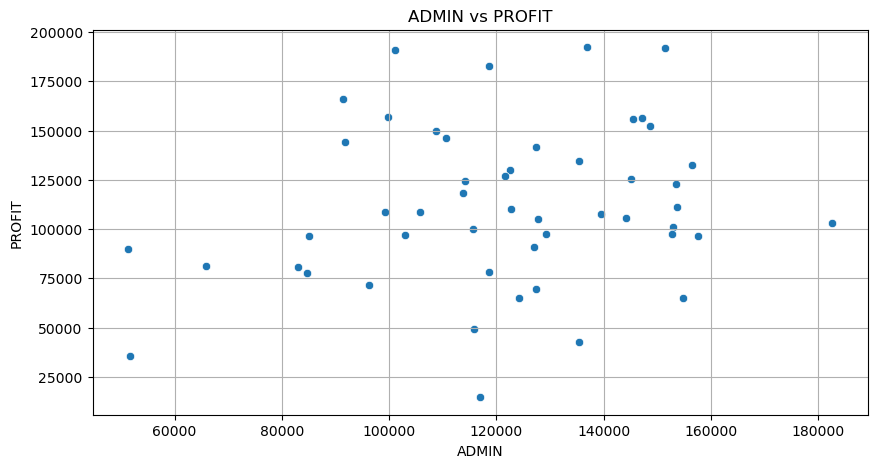

In [10]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="ADMIN", y="PROFIT")
plt.title("ADMIN vs PROFIT")
plt.grid()
plt.show()

### ADMIN and PROFIT do not have a relationship

### Create a scatterplot on MKT vs PROFIT

In [ ]:
sns.scatterplot(data=df, x="MKT",y="PROFIT")

<Axes: xlabel='MKT', ylabel='PROFIT'>

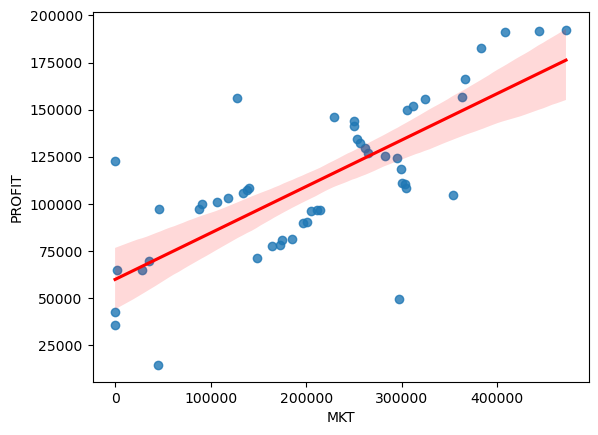

In [11]:
sns.regplot(data=df, x="MKT",y="PROFIT", line_kws={"color":"red"})

### Seperate Categorical and Continuous features

In [12]:
df.dtypes

RND       float64
ADMIN     float64
MKT       float64
STATE      object
PROFIT    float64
dtype: object

In [13]:
df.columns

Index(['RND', 'ADMIN', 'MKT', 'STATE', 'PROFIT'], dtype='object')

In [14]:
cat = list(df.columns[df.dtypes=="object"])
cat

['STATE']

In [15]:
con = list(df.columns[df.dtypes!="object"])
con

['RND', 'ADMIN', 'MKT', 'PROFIT']

### Basic steps in the EDA
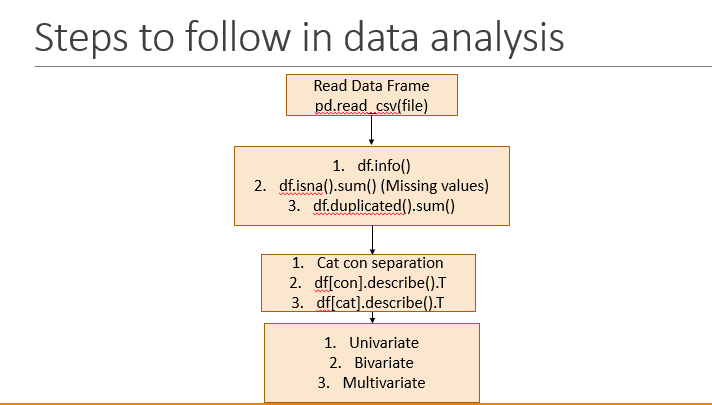

### Step 1: Read the dataset

In [18]:

A = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\flipkart_laptops.csv",  encoding='latin1')
A.head()

,Name,Brand,Sellig Price,MRP,Discount,Ratings,No_of_ratings,Details
0,Lenovo IdeaPad 3 Core i3 11th Gen - (8 GB/256 ...,Lenovo,36990,60890,39% off,4.2,670 Ratings & 54 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...
1,Lenovo IdeaPad 3 Core i3 11th Gen - (8 GB/512 ...,Lenovo,37990,59390,36% off,4.2,3803 Ratings & 362 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...
2,ASUS VivoBook 15 (2022) Core i3 10th Gen - (8 ...,ASUS,32990,45990,28% off,4.3,8727 Ratings & 876 Reviews,['Intel Core i3 Processor (10th Gen)' '8 GB DD...
3,realme Book (Slim) Core i3 11th Gen - (8 GB/25...,realme,46990,54999,14% off,4.4,11894 Ratings & 1773 Reviews,['Stylish & Portable Thin and Light Laptop' '1...
4,DELL Inspiron Core i3 11th Gen - (8 GB/1 TB HD...,DELL,38990,61202,36% off,4.3,65 Ratings & 6 Reviews,['Processor: Intel i3-1115G4 (Base- 1.70 GHz &...


### Step 2: Perform basic data quality checks

In [19]:
A.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           414 non-null    object 
 1   Brand          414 non-null    object 
 2   Sellig Price   414 non-null    int64  
 3   MRP            414 non-null    int64  
 4   Discount       414 non-null    object 
 5   Ratings        414 non-null    float64
 6   No_of_ratings  414 non-null    object 
 7   Details        414 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 26.0+ KB


In [20]:
A.isna().sum()

Name             0
Brand            0
Sellig Price     0
MRP              0
Discount         0
Ratings          0
No_of_ratings    0
Details          0
dtype: int64

In [21]:
A.duplicated().sum()

0

### Drop the duplicates

In [22]:
A = A.drop_duplicates(keep="first")
A = A.reset_index(drop=True)

In [23]:
A.shape

(414, 8)

In [24]:
A

,Name,Brand,Sellig Price,MRP,Discount,Ratings,No_of_ratings,Details
0,Lenovo IdeaPad 3 Core i3 11th Gen - (8 GB/256 ...,Lenovo,36990,60890,39% off,4.2,670 Ratings & 54 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...
1,Lenovo IdeaPad 3 Core i3 11th Gen - (8 GB/512 ...,Lenovo,37990,59390,36% off,4.2,3803 Ratings & 362 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...
2,ASUS VivoBook 15 (2022) Core i3 10th Gen - (8 ...,ASUS,32990,45990,28% off,4.3,8727 Ratings & 876 Reviews,['Intel Core i3 Processor (10th Gen)' '8 GB DD...
3,realme Book (Slim) Core i3 11th Gen - (8 GB/25...,realme,46990,54999,14% off,4.4,11894 Ratings & 1773 Reviews,['Stylish & Portable Thin and Light Laptop' '1...
4,DELL Inspiron Core i3 11th Gen - (8 GB/1 TB HD...,DELL,38990,61202,36% off,4.3,65 Ratings & 6 Reviews,['Processor: Intel i3-1115G4 (Base- 1.70 GHz &...
...,...,...,...,...,...,...,...,...
409,DELL Inspiron Core i3 11th Gen - (8 GB/1 TB HD...,DELL,45890,58567,21% off,4.3,406 Ratings & 36 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...
410,acer Swift 3 Core i5 11th Gen Intel EVO - (8 G...,acer,68500,72999,6% off,4.4,42 Ratings & 9 Reviews,['Intel Evo platform feat 11th Gen Intel Core ...
411,HP Pavilion Ryzen 7 Octa Core AMD R7-5800H - (...,HP,90000,103215,12% off,4.6,289 Ratings & 40 Reviews,['AMD Ryzen 7 Octa Core Processor' '16 GB DDR4...
412,ASUS VivoBook Ultra 14 Core i3 11th Gen - (8 G...,ASUS,44490,56990,21% off,4.4,2807 Ratings & 401 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...


In [25]:
A.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           414 non-null    object 
 1   Brand          414 non-null    object 
 2   Sellig Price   414 non-null    int64  
 3   MRP            414 non-null    int64  
 4   Discount       414 non-null    object 
 5   Ratings        414 non-null    float64
 6   No_of_ratings  414 non-null    object 
 7   Details        414 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 26.0+ KB


## Descriptive analytics

In [26]:
cat = list(A.columns[A.dtypes=="object"])
cat

['Name', 'Brand', 'Discount', 'No_of_ratings', 'Details']

In [27]:
con = list(A.columns[A.dtypes!="object"])
con

['Sellig Price', 'MRP', 'Ratings']

In [28]:
A[cat].describe().T

,count,unique,top,freq
Name,414,404,ASUS TUF Gaming F15 Core i5 10th Gen - (8 GB/1...,2
Brand,414,17,ASUS,120
Discount,414,44,25% off,26
No_of_ratings,414,329,3 Ratings & 0 Reviews,13
Details,414,385,['Apple M1 Processor' '8 GB DDR4 RAM' 'Mac OS ...,3


In [29]:
A[con].describe().T

,count,mean,std,min,25%,50%,75%,max
Sellig Price,414.0,69708.077295,42953.589855,14990.0,40990.0,59685.0,81742.5,309490.0
MRP,414.0,89741.393720,50538.944474,24418.0,56171.5,76990.0,106763.0,350990.0
Ratings,414.0,4.284300,0.333620,2.5,4.1,4.3,4.5,5.0


### Univarite analysis

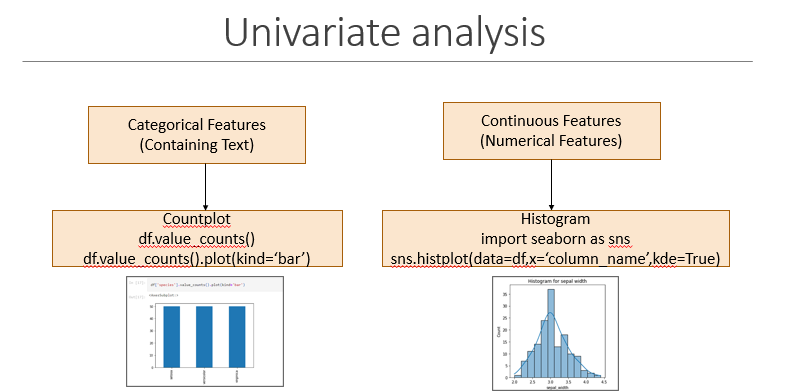

In [34]:
print(A.columns)


Index(['Name', 'Brand', 'Sellig Price', 'MRP', 'Discount', 'Ratings',
       'No_of_ratings', 'Details'],
      dtype='object')


In [35]:
A.columns = A.columns.str.strip()  # Remove any leading/trailing spaces


<Axes: xlabel='Brand', ylabel='count'>

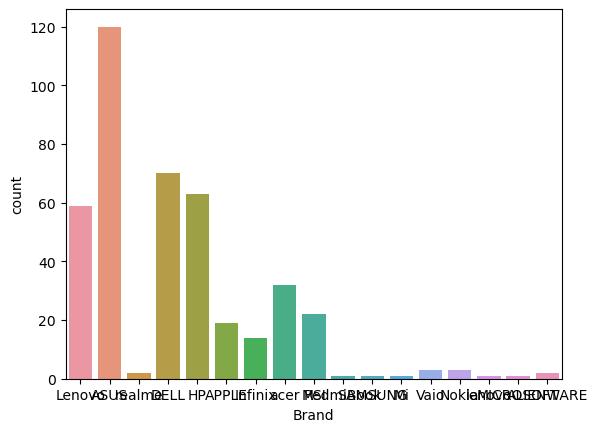

In [37]:
sns.countplot(data=A, x="Brand")

### Countplot is for catgorical features

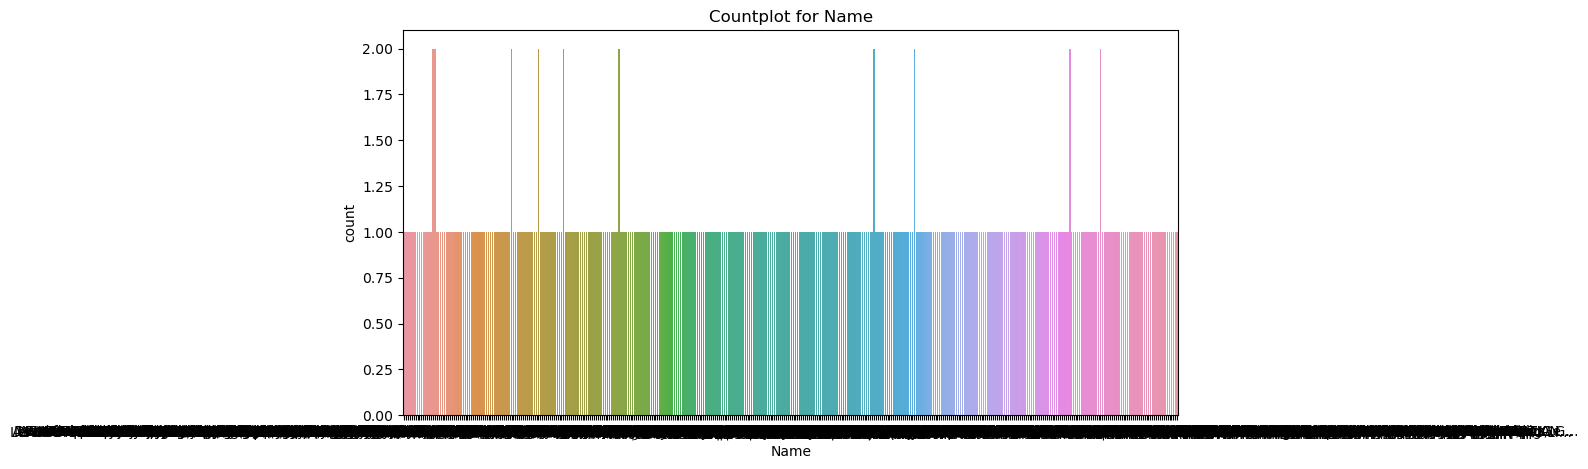

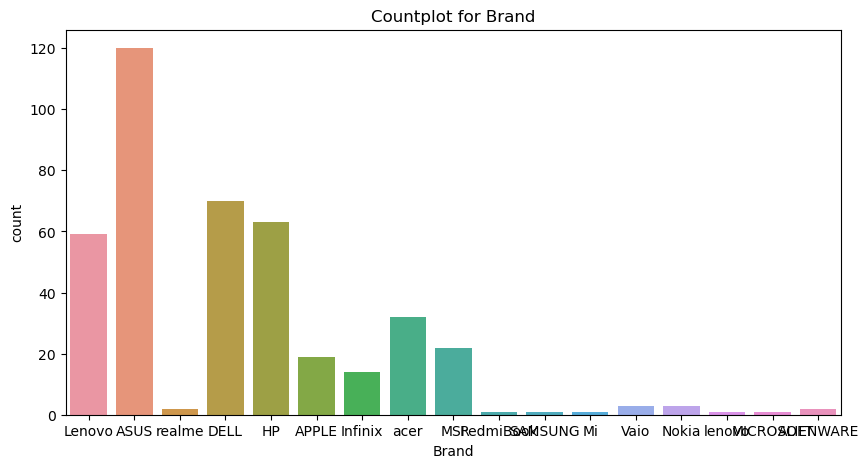

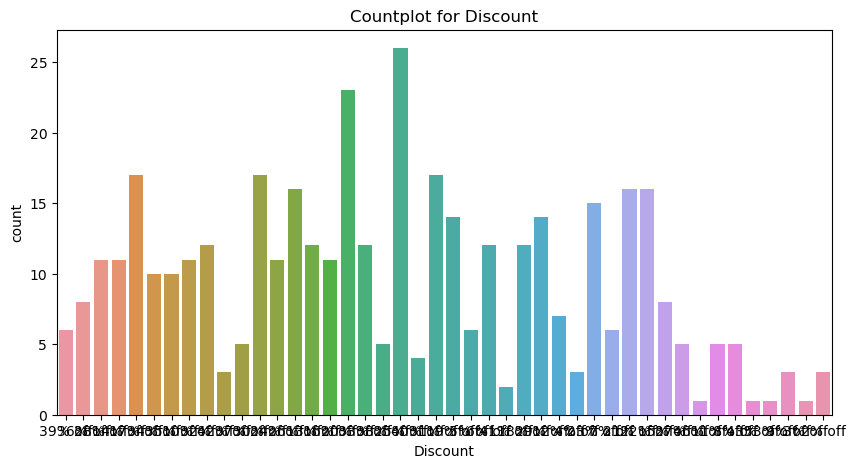

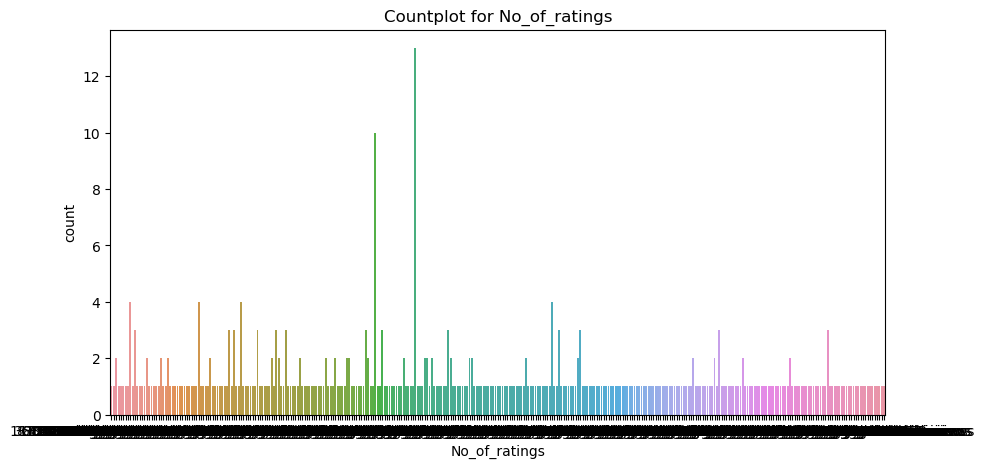

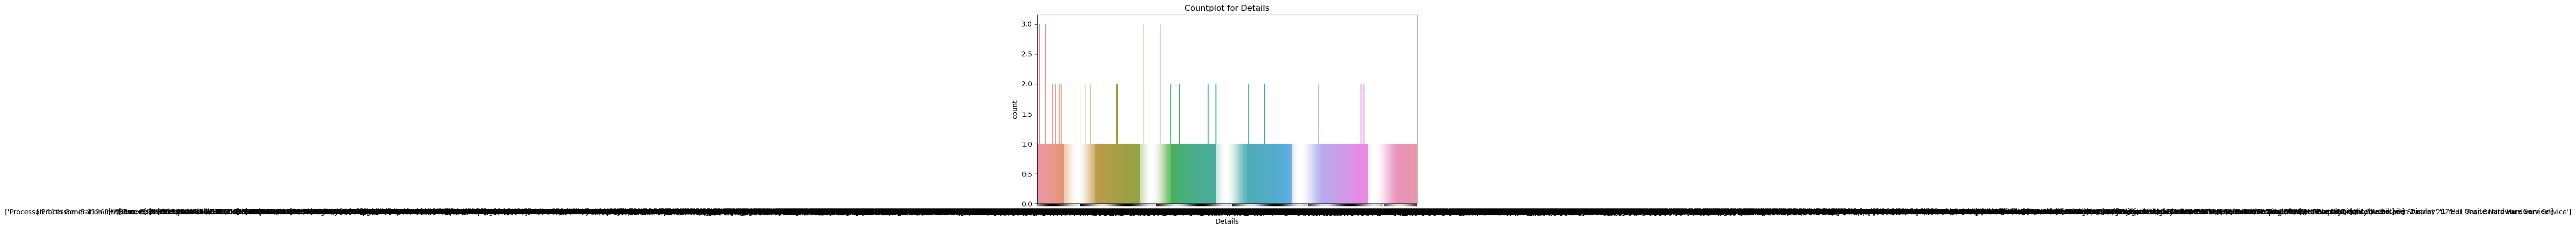

In [32]:
for i in cat:
    plt.figure(figsize=(10,5))
    sns.countplot(data=A, x=i)
    plt.title(f"Countplot for {i}")
    plt.show()

<Axes: xlabel='No_of_ratings', ylabel='Count'>

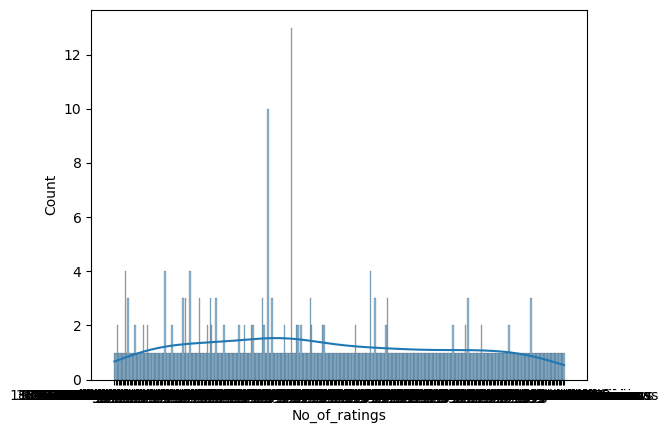

In [41]:
sns.histplot(data=A, x='No_of_ratings', kde=True)

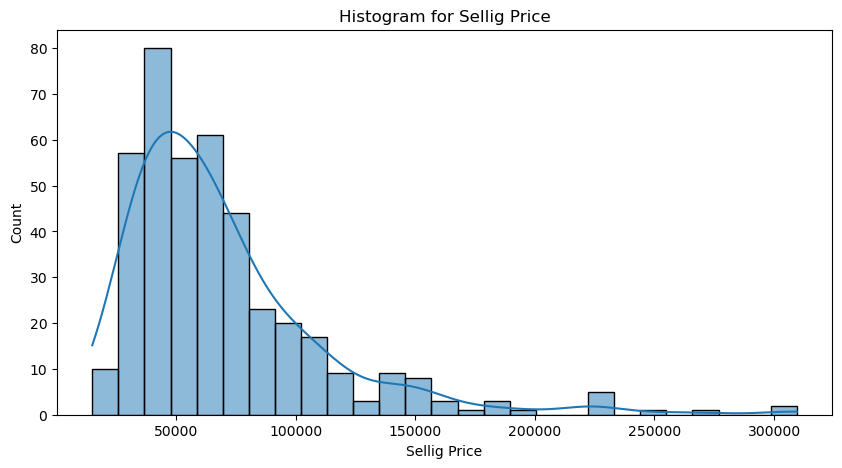

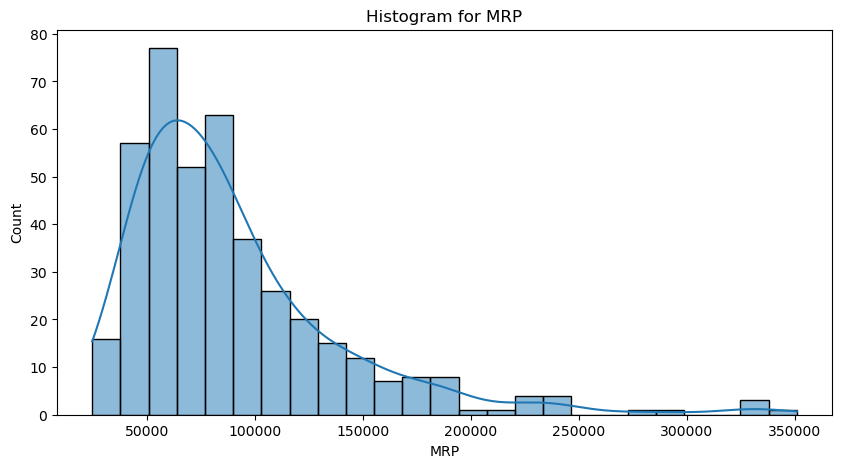

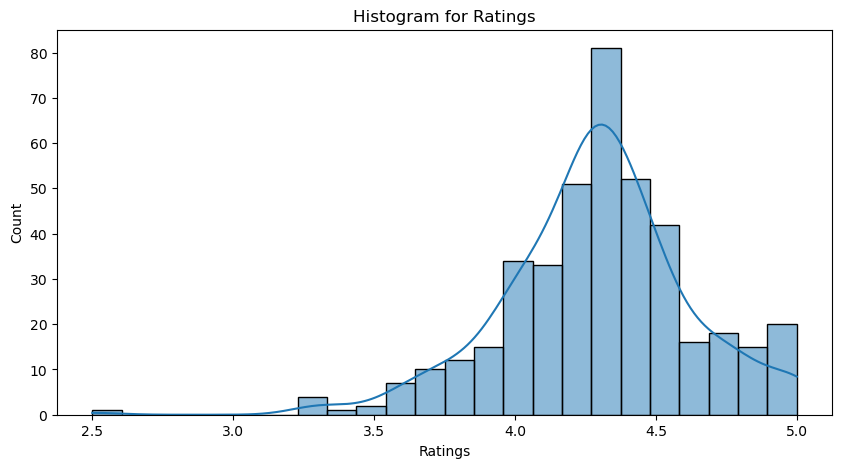

In [38]:
for i in con:
    plt.figure(figsize=(10,5))
    sns.histplot(data=A, x=i, kde=True)
    plt.title(f"Histogram for {i}")
    plt.show()

### Bivariate analysis

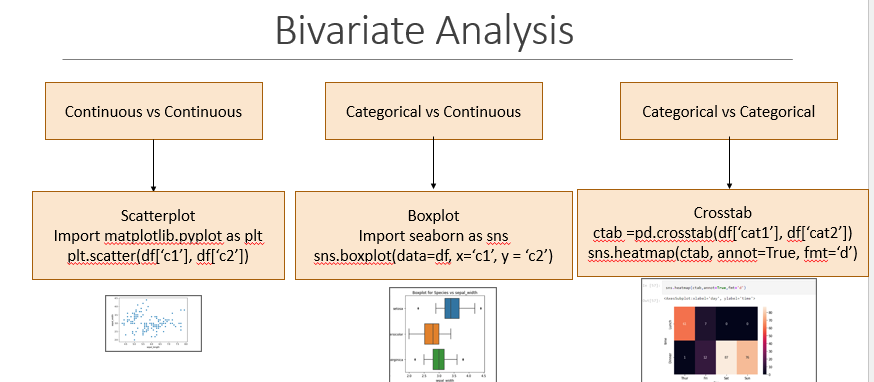

In [39]:
con

['Sellig Price', 'MRP', 'Ratings']

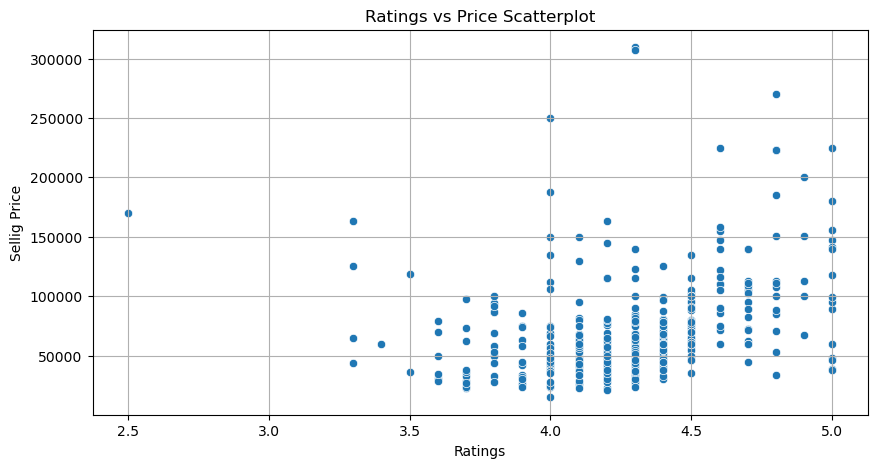

In [58]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=A, x='Ratings', y='Sellig Price')
plt.title("Ratings vs Price Scatterplot")
plt.grid()
plt.show()

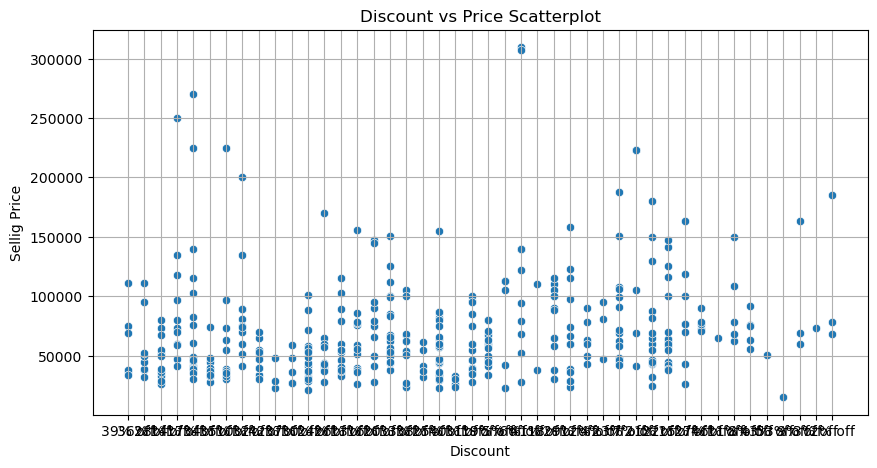

In [51]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=A, x='Discount', y='Sellig Price')
plt.title("Discount vs Price Scatterplot")
plt.grid()
plt.show()

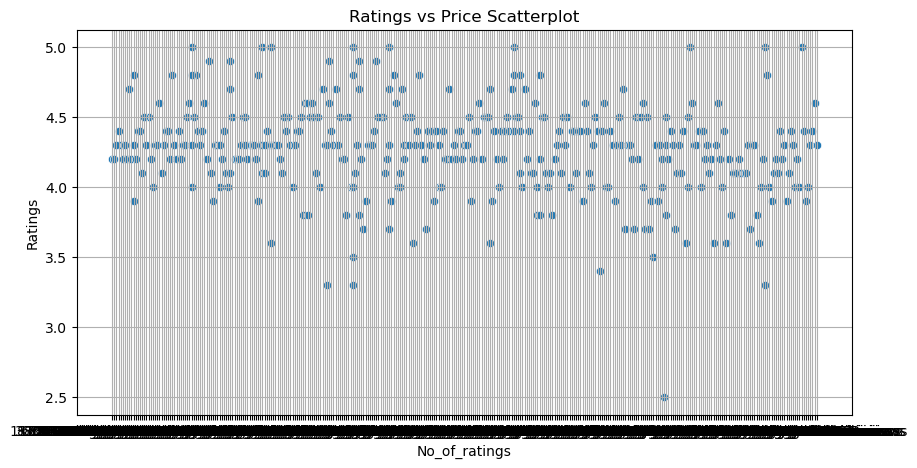

In [59]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=A, x='No_of_ratings', y='Ratings')
plt.title("Ratings vs Price Scatterplot")
plt.grid()
plt.show()

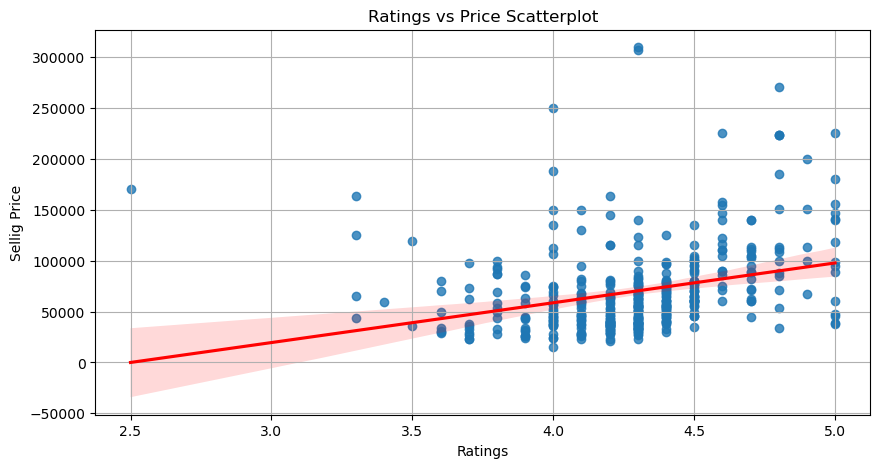

In [60]:
plt.figure(figsize=(10, 5))
sns.regplot(data=A, x='Ratings', y='Sellig Price', line_kws={"color":"red"})
plt.title("Ratings vs Price Scatterplot")
plt.grid()
plt.show()

### As number of ratings increase number of Reviews also increases linearly

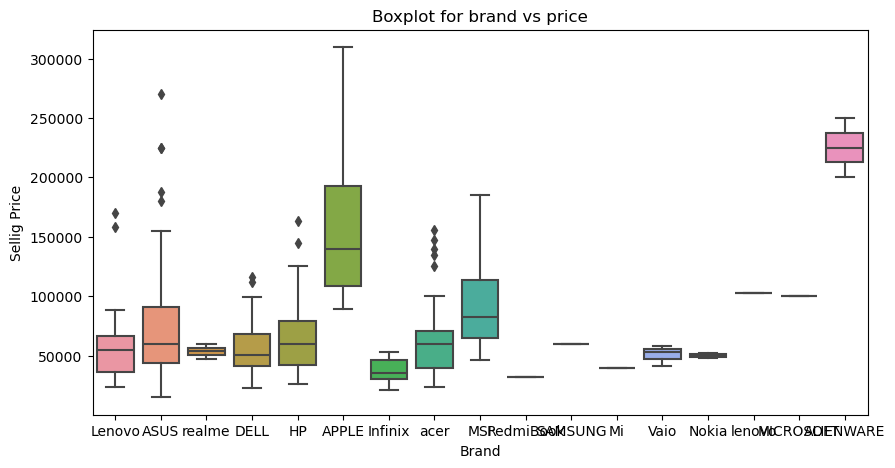

In [47]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=A, x="Brand", y="Sellig Price")
plt.title("Boxplot for brand vs price")
plt.show()

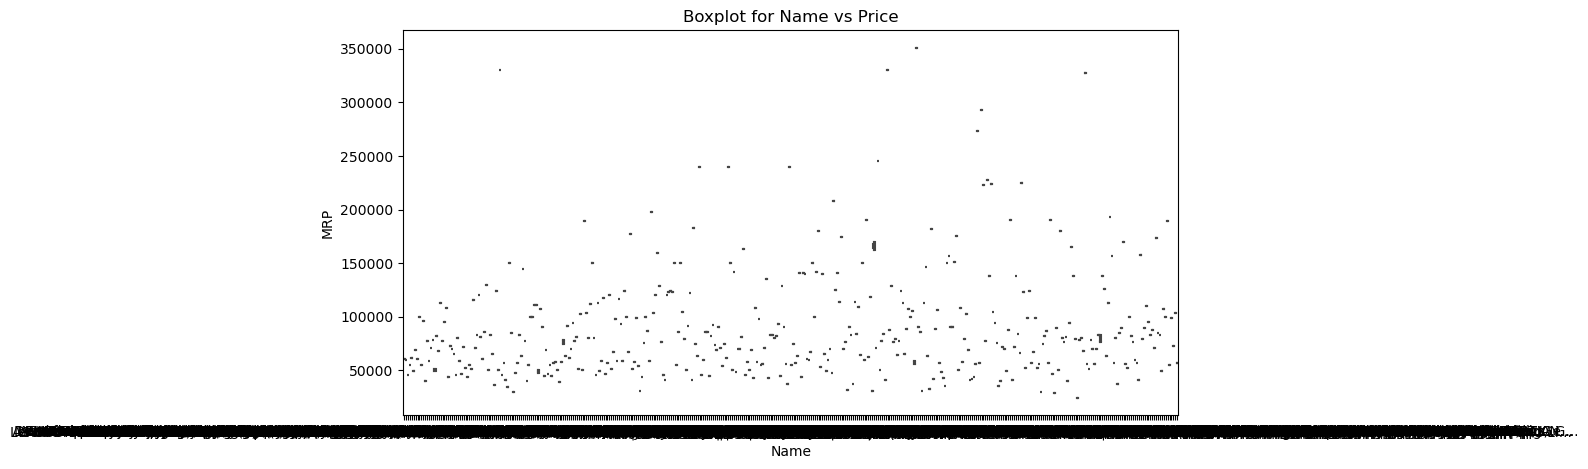

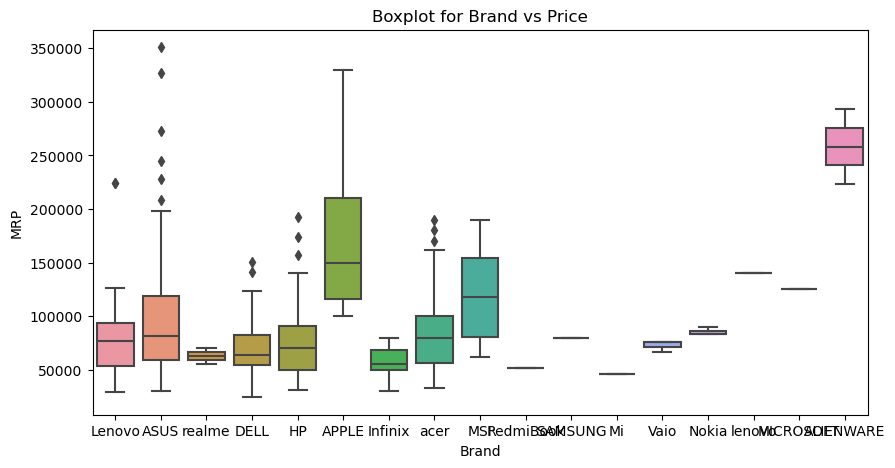

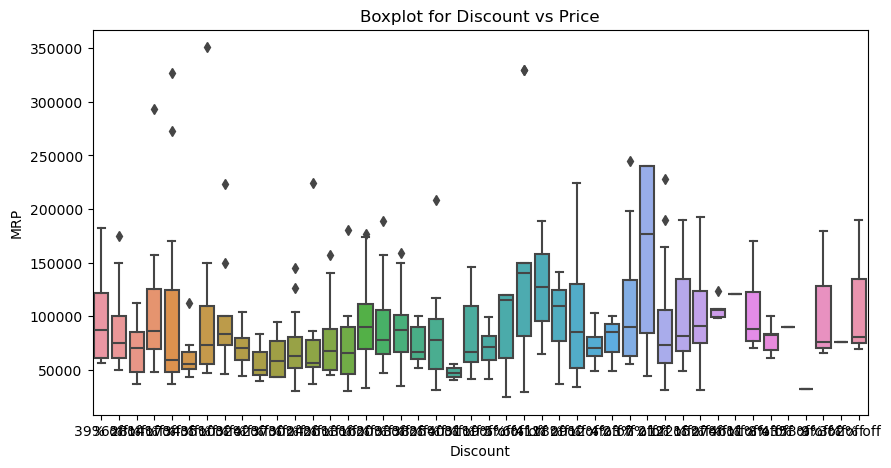

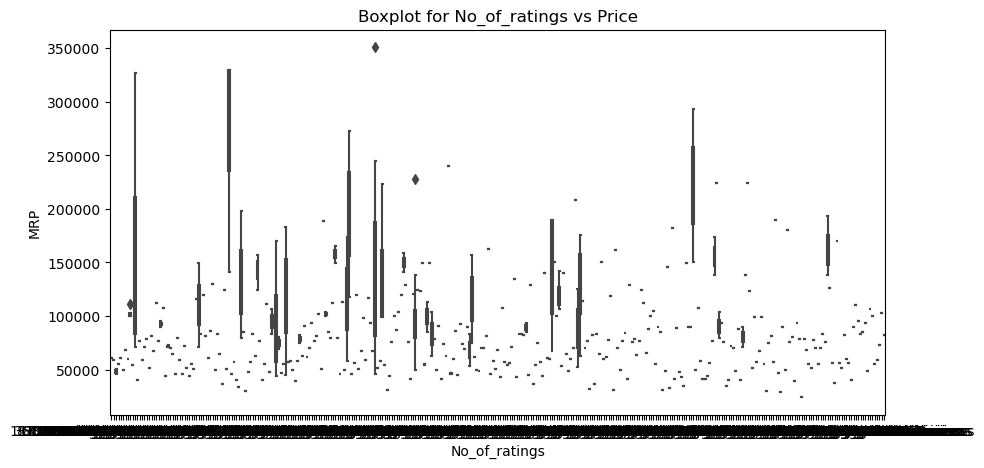

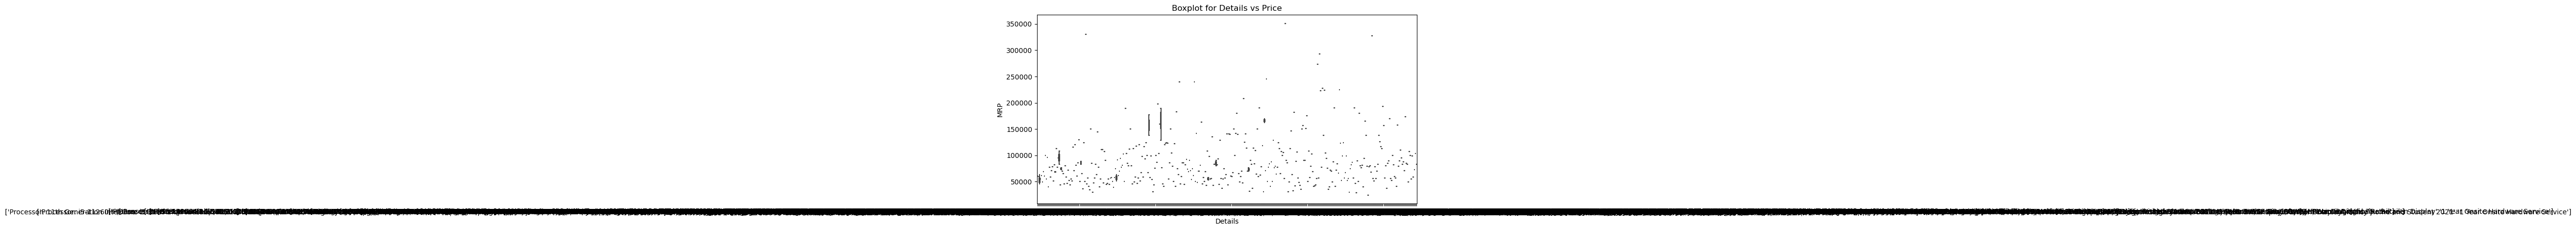

In [62]:
for i in cat:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=A, x=i, y= "MRP")
    plt.title(f"Boxplot for {i} vs Price")
    plt.show()

### Categorical vs Categorical - crosstab heatmap

In [64]:
cat

['Name', 'Brand', 'Discount', 'No_of_ratings', 'Details']

In [72]:
ctab1 = pd.crosstab(A['No_of_ratings'], A['Brand'])
ctab1

Brand,ALIENWARE,APPLE,ASUS,DELL,HP,Infinix,Lenovo,MICROSOFT,MSI,Mi,Nokia,RedmiBook,SAMSUNG,Vaio,acer,lenovo,realme
No_of_ratings,,,,,,,,,,,,,,,,,
1 Ratings & 1 Reviews,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
10 Ratings & 1 Reviews,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10 Ratings & 2 Reviews,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10 Ratings & 3 Reviews,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
10 Ratings & 4 Reviews,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97 Ratings & 10 Reviews,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
98 Ratings & 23 Reviews,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
98 Ratings & 4 Reviews,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='Brand', ylabel='No_of_ratings'>

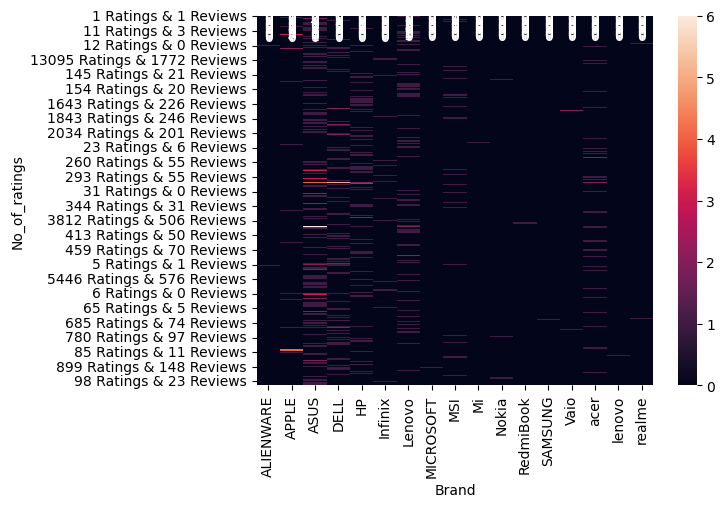

In [74]:
sns.heatmap(ctab1, annot=True, fmt="d")

In [76]:
ctab2 = pd.crosstab(A['Brand'], A['Discount'])
ctab2

Discount,10% off,11% off,12% off,13% off,14% off,15% off,16% off,17% off,18% off,19% off,...,41% off,42% off,43% off,46% off,5% off,53% off,6% off,7% off,8% off,9% off
Brand,,,,,,,,,,,,,,,,,,,,,
ALIENWARE,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
APPLE,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,4,0,7,4,0,1
ASUS,0,2,0,1,0,3,6,4,7,5,...,0,0,0,0,0,1,0,0,0,0
DELL,1,1,1,2,2,0,1,3,1,3,...,0,0,0,0,2,0,1,1,2,0
HP,4,1,4,6,5,5,2,6,1,5,...,0,0,0,0,0,0,2,1,2,1
Infinix,0,0,0,0,0,0,0,0,0,0,...,1,2,0,0,0,0,0,0,0,0
Lenovo,1,0,1,1,0,0,1,1,1,1,...,0,0,0,1,0,0,1,0,1,0
MICROSOFT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MSI,1,1,0,0,1,0,0,1,2,0,...,1,0,0,0,0,0,0,0,0,0


<Axes: xlabel='Discount', ylabel='Brand'>

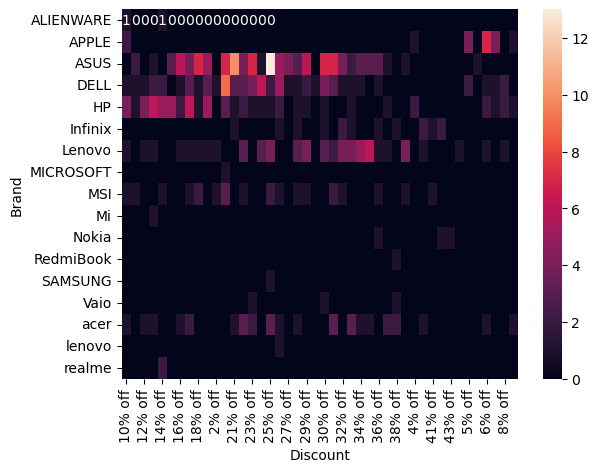

In [77]:
sns.heatmap(ctab2, annot=True, fmt="d")

### Mutivariate 
1. Pairplot
2. Correlation heatmap

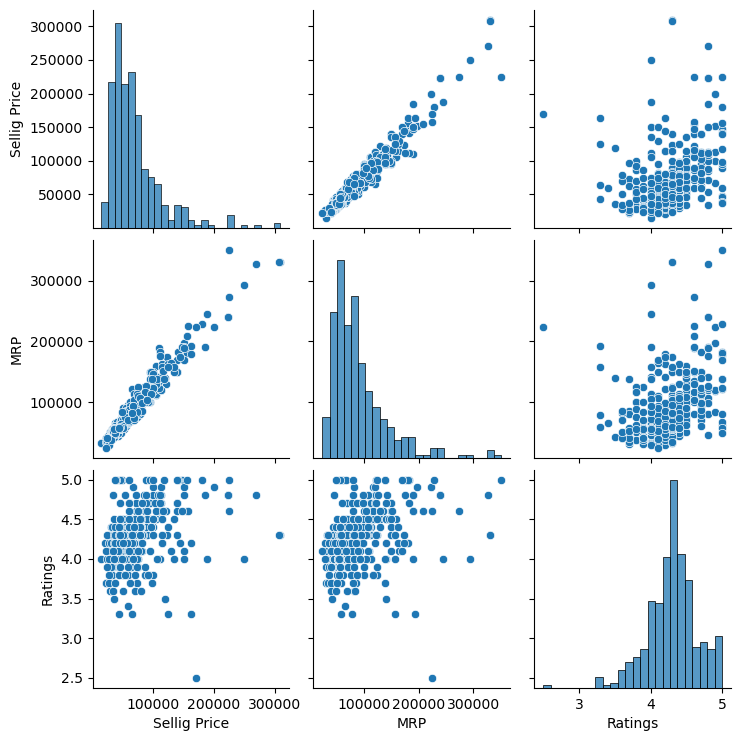

In [78]:
sns.pairplot(data=A)

In [79]:
cat

['Name', 'Brand', 'Discount', 'No_of_ratings', 'Details']

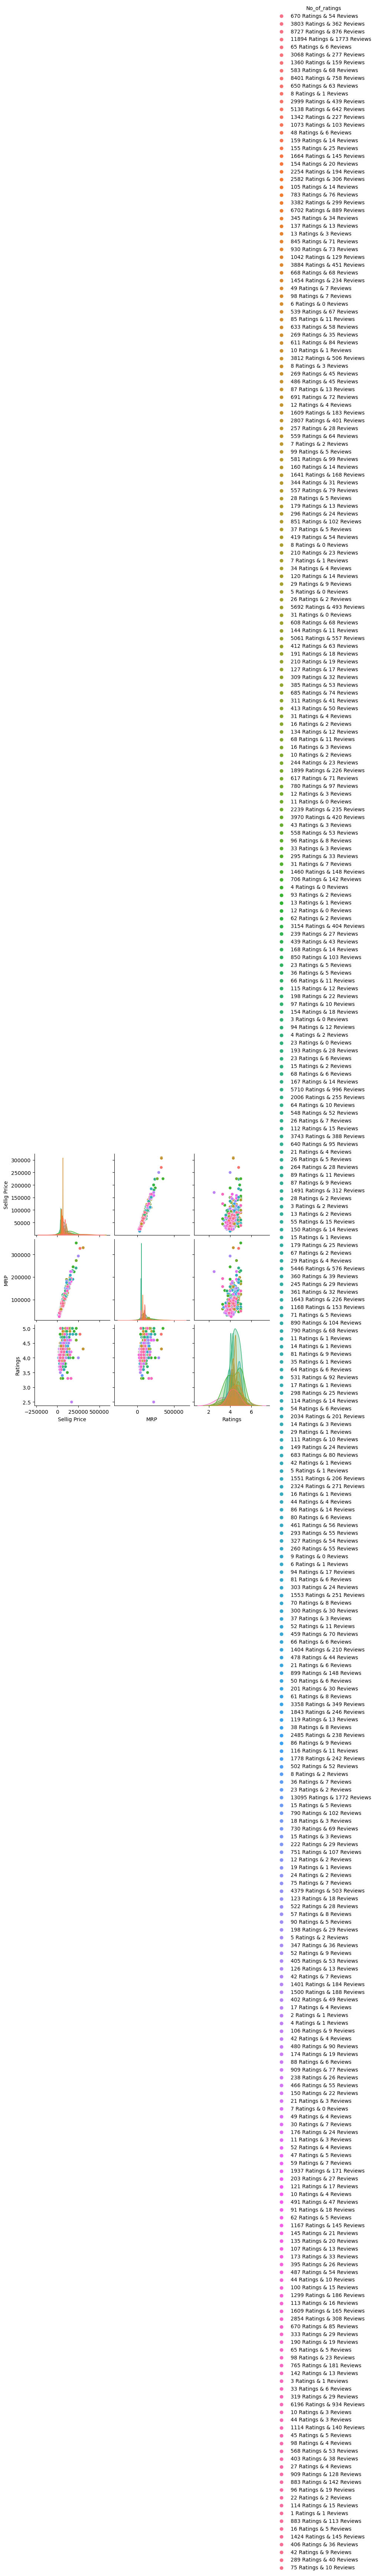

In [83]:
sns.pairplot(data=A, hue='No_of_ratings')

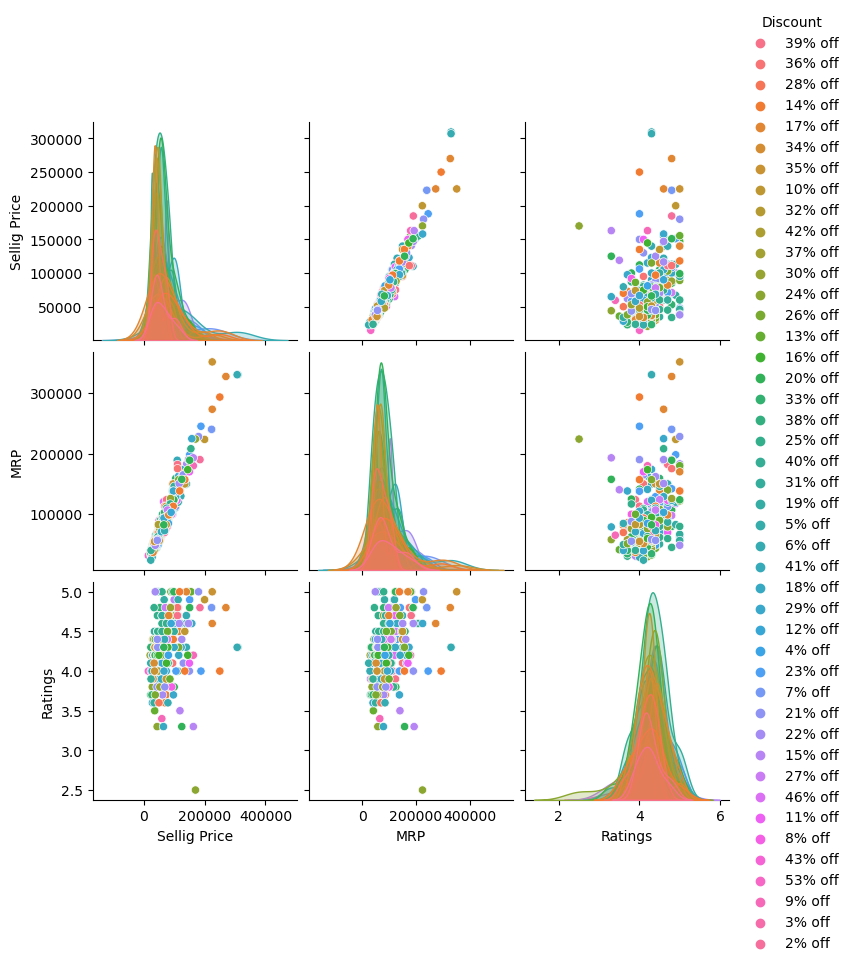

In [84]:
sns.pairplot(data=A, hue='Discount')

### Correlation heatmap

In [85]:
c = A[con].corr()

In [86]:
c

,Sellig Price,MRP,Ratings
Sellig Price,1.000000,0.972808,0.303529
MRP,0.972808,1.000000,0.308342
Ratings,0.303529,0.308342,1.000000


<Axes: >

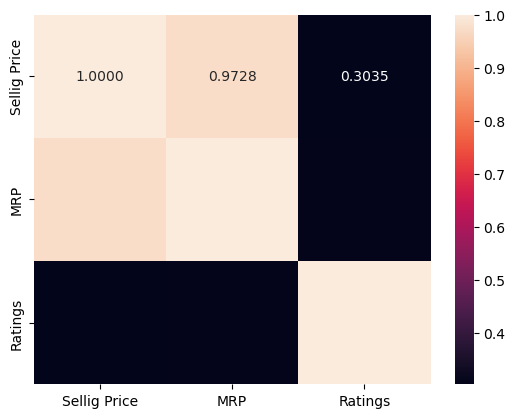

In [87]:
sns.heatmap(c, annot=True, fmt=".4f")

### Extra

### Show the average price of laptops by brand

In [91]:
B = A.groupby(by="Brand").agg({"Sellig Price":"mean"}).sort_values(by="Sellig Price")
B

,Sellig Price
Brand,
RedmiBook,31990.000000
Infinix,36847.142857
Mi,39990.000000
Nokia,50323.333333
Vaio,50656.666667
realme,53490.000000
Lenovo,55254.440678
DELL,55861.642857
SAMSUNG,59990.000000


<Axes: ylabel='Brand'>

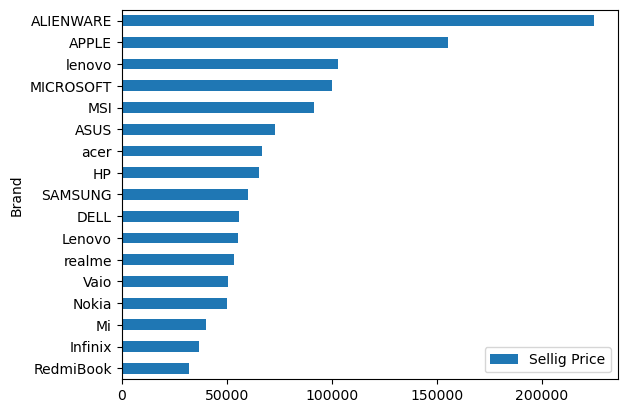

In [92]:
B.plot(kind='barh')

In [93]:
cat

['Name', 'Brand', 'Discount', 'No_of_ratings', 'Details']

### Get the median price by processor brand and processor name

In [94]:
C = A.groupby(by=["Brand", "Name"]).agg({"Sellig Price":"median"})
C

Sellig Price
Brand     Name                                                            
ALIENWARE ALIENWARE Core i7 10th Gen - (16 GB/1 TB SSD/Wi...      250000.0
          ALIENWARE Core i7 10th Gen - (16 GB/512 GB SSD/...      199990.0
APPLE     APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/Ma...       88990.0
          APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/Ma...       88990.0
          APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/Ma...       94990.0
...                                                                    ...
acer      acer Travelmate Core i3 11th Gen - (8 GB/1 TB H...       46040.0
          acer aspire 5 gaming Core i5 12th Gen - (8 GB/5...       61999.0
lenovo    lenovo Yoga 7 Core i7 11th Gen Intel EVO - (16 ...      102990.0
realme    realme Book (Slim) Core i3 11th Gen - (8 GB/256...       46990.0
          realme Book(Slim) Intel Evo Core i5 11th Gen - ...       59990.0

[404 rows x 1 columns]

<Axes: ylabel='Brand,Name'>

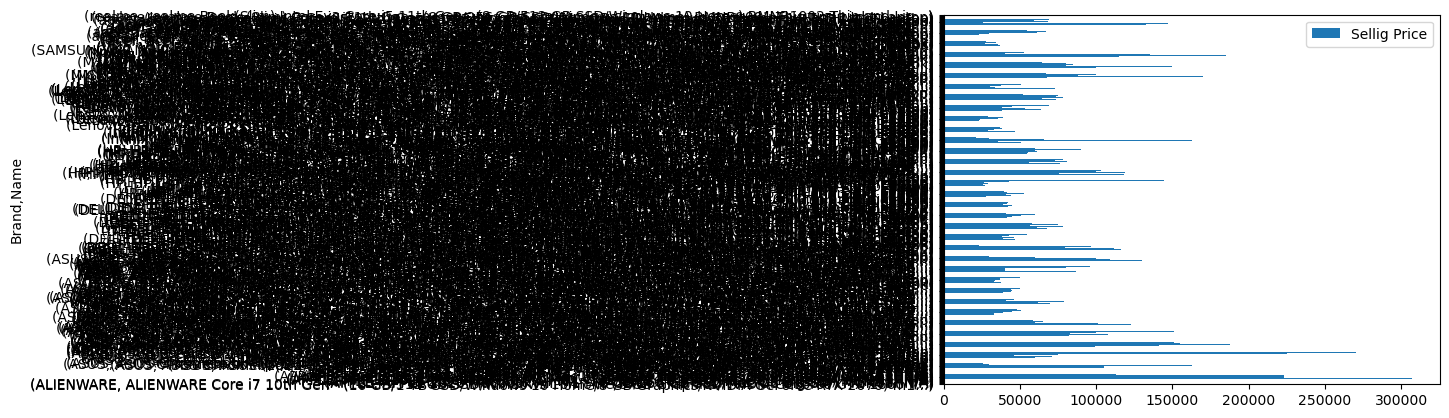

In [95]:
C.plot(kind="barh")